# **End to End Neural Network for Portfolio Optimization**

**Import Libraries**

In [56]:
#Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

**ETFs Description**

We are using 10 diversified ETFs spanning US equity (large/small/tech), international (developed/emerging), fixed income (corporate/treasury), and real assets (gold, real estate, energy) from period of 2015 to 2025.

In [57]:
# ETFs
ticker_info = {
    "EEM": {"name": "iShares MSCI Emerging Markets ETF",            "asset_class": "Emerging Market Equity"},
    "EFA": {"name": "iShares MSCI EAFE ETF",                        "asset_class": "International Developed Market Equity"},
    "GLD": {"name": "SPDR Gold Shares ETF",                         "asset_class": "Commodities/Gold"},
    "IWM": {"name": "iShares Russell 2000 ETF",                     "asset_class": "US Small Cap Equity"},
    "LQD": {"name": "iShares Investment Grade Corporate Bond ETF",  "asset_class": "Corporate Bonds"},
    "QQQ": {"name": "Invesco Nasdaq-100 ETF",                       "asset_class": "US Tech Equity"},
    "SPY": {"name": "SPDR S&P 500 ETF Trust",                       "asset_class": "US Large Cap Equity"},
    "TLT": {"name": "iShares 20+ Year Treasury Bond ETF",           "asset_class": "Long-term US Bonds"},
    "VNQ": {"name": "Vanguard Real Estate ETF",                     "asset_class": "Real Estate"},
    "XLE": {"name": "Energy Select Sector SPDR ETF",                "asset_class": "Energy"},
}

ticker_df = pd.DataFrame(ticker_info).T.rename_axis("Ticker").reset_index()
ticker_df.index += 1
col_widths = {col: max(ticker_df[col].str.len().max(), len(col)) + 3
              for col in ticker_df.columns}

header = "".join(col.ljust(col_widths[col]) for col in ticker_df.columns)

print(header)
print("-" * len(header))
for idx, row in ticker_df.iterrows():
    print("".join(str(row[col]).ljust(col_widths[col]) for col in ticker_df.columns))
print(f"Total ETFs: {len(ticker_df)}")

Ticker   name                                          asset_class                             
-----------------------------------------------------------------------------------------------
EEM      iShares MSCI Emerging Markets ETF             Emerging Market Equity                  
EFA      iShares MSCI EAFE ETF                         International Developed Market Equity   
GLD      SPDR Gold Shares ETF                          Commodities/Gold                        
IWM      iShares Russell 2000 ETF                      US Small Cap Equity                     
LQD      iShares Investment Grade Corporate Bond ETF   Corporate Bonds                         
QQQ      Invesco Nasdaq-100 ETF                        US Tech Equity                          
SPY      SPDR S&P 500 ETF Trust                        US Large Cap Equity                     
TLT      iShares 20+ Year Treasury Bond ETF            Long-term US Bonds                      
VNQ      Vanguard Real Estate ETF       

# **Data & Features**

**Download dataset from yfinance**

In [58]:
tickers = list(ticker_info.keys())
data = yf.download(tickers, start="2015-01-01", end="2025-12-31", auto_adjust=True)
prices = data["Close"]
prices.head()

[*********************100%***********************]  10 of 10 completed


Ticker,EEM,EFA,GLD,IWM,LQD,QQQ,SPY,TLT,VNQ,XLE
Date,,,,,,,,,,
2015-01-02,30.355043,43.780632,114.080002,102.786987,80.710709,94.665100,170.125031,93.367317,52.549866,25.548061
2015-01-05,29.814816,42.747181,115.800003,101.412796,81.040695,93.276451,167.052597,94.833939,52.837479,24.491192
2015-01-06,29.689545,42.262981,117.120003,99.658333,81.370773,92.025764,165.479080,96.542603,53.361568,24.131397
2015-01-07,30.331570,42.732727,116.430000,100.885597,81.478508,93.212067,167.541199,96.351944,54.179668,24.182796
2015-01-08,30.848314,43.310871,115.940002,102.596817,81.215843,94.996124,170.514252,95.075966,54.384186,24.725702


**Data Preprocessing**

In [101]:
# Check for missing values
print("Missing values for each \n", prices.isnull().sum())
# Check start and end date
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
# Check shape
print(prices.shape)

Missing values for each 
 Ticker
EEM    0
EFA    0
GLD    0
IWM    0
LQD    0
QQQ    0
SPY    0
TLT    0
VNQ    0
XLE    0
dtype: int64
Date range: 2015-01-02 → 2025-12-30
(2765, 10)


**Feature Engineering**

In [60]:
# Compute daily returns
returns = prices.pct_change().dropna()

# Lagged returns (1, 3, 5 days)
lagged = pd.concat([returns.shift(lag).add_suffix(f"_lag{lag}") for lag in [1, 3, 5]], axis=1)

# Rolling volatility (5, 21 days)
volatility = pd.concat([returns.rolling(w).std().add_suffix(f"_vol{w}") for w in [5, 21]], axis=1)

# Moving average ratios (10, 21, 63 days)
ma_features = pd.concat([(prices / prices.rolling(w).mean() - 1).add_suffix(f"_ma{w}") for w in [10, 21, 63]], axis=1)

# Momentum (21, 63 days)
momentum = pd.concat([returns.rolling(w).sum().add_suffix(f"_mom{w}") for w in [21, 63]], axis=1)

# Combine all newly engineered features and drop NaNs from rolling window burn-in
# First momentum value is computed using first 63 rows and record in 64 row, so earlier rows are blank which are removed
features = pd.concat([returns, lagged, volatility, ma_features, momentum], axis=1).dropna()

# Summary
print(f"Shape      : {features.shape}")
print(f"Date range : {features.index[0].date()} → {features.index[-1].date()}")
print(f"Features   : {features.shape[1]} cols across {features.shape[0]} trading days")
features.head()

Shape      : (2702, 110)
Date range : 2015-04-06 → 2025-12-30
Features   : 110 cols across 2702 trading days


Ticker,EEM,EFA,GLD,IWM,LQD,QQQ,SPY,TLT,VNQ,XLE,...,EEM_mom63,EFA_mom63,GLD_mom63,IWM_mom63,LQD_mom63,QQQ_mom63,SPY_mom63,TLT_mom63,VNQ_mom63,XLE_mom63
Date,,,,,,,,,,,,,,,,,,,,,
2015-04-06,0.012851,0.010125,0.012231,0.004413,0.001316,0.008181,0.006733,-0.005584,0.010373,0.018013,...,0.079056,0.086609,0.025919,0.057321,0.024078,0.034156,0.018426,0.030476,0.051438,0.008490
2015-04-07,-0.005028,-0.001367,-0.004970,-0.006390,0.003615,-0.001698,-0.002646,0.008384,-0.017617,0.000631,...,0.091825,0.108847,0.005872,0.064300,0.023605,0.047127,0.033839,0.023152,0.028348,0.050490
2015-04-08,0.020934,0.004258,-0.005512,0.008601,-0.000327,0.007939,0.003377,0.000305,0.001544,-0.008083,...,0.116961,0.124432,-0.011039,0.090201,0.019206,0.068475,0.046636,0.005440,0.019973,0.057097
2015-04-09,0.009898,0.001363,-0.006928,-0.003586,-0.005079,0.006283,0.004423,-0.012964,-0.020752,0.016045,...,0.105234,0.114680,-0.012076,0.074300,0.012802,0.061867,0.038598,-0.005550,-0.016110,0.071012
2015-04-10,0.000700,0.001966,0.011337,0.004799,0.001400,0.004100,0.005457,0.001468,-0.000727,0.004387,...,0.088898,0.103117,0.003469,0.062137,0.017426,0.046827,0.026309,0.009161,-0.020612,0.052949


# **Benchmark Portfolio**

**Mean-Variance Optimization (MVO)**

For diversification, we have restricted the maximum weight allocation to 20% for any individual asset

In [61]:
# Train/Val/Test split (70/15/15) + MVO benchmark
n = len(features)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Index split for train, validation and test
train_idx, val_idx, test_idx = features.index[:train_end], features.index[train_end:val_end], features.index[val_end:]

# Return split using train, validation and test indices
train_r, val_r, test_r       = returns.loc[train_idx], returns.loc[val_idx], returns.loc[test_idx]
print(f"Train : {train_idx[0].date()} → {train_idx[-1].date()} ({len(train_idx)} days)")
print(f"Val   : {val_idx[0].date()} → {val_idx[-1].date()} ({len(val_idx)} days)")
print(f"Test  : {test_idx[0].date()} → {test_idx[-1].date()} ({len(test_idx)} days)")

# Compute Sharpe ratio on train data assuming risk-free rate ≈ 0
mu, cov, n_assets = train_r.mean().values, train_r.cov().values, len(returns.columns)

# Define neg_sharpe ratio function which is iteratively called to optimize weights
def neg_sharpe(w):
    return -(w @ mu * 252) / np.sqrt(w @ cov @ w * 252)

# Call minimize function
result = minimize(neg_sharpe,
            # starting weight equal to 1 for all assets and this goes as w in neg_sharpe function
            np.ones(n_assets) / n_assets,
            method="SLSQP",
            # restriction on individual asset's weight value
            bounds=[(0, 0.2)] * n_assets,
            # equality (to zero) holds for w.sum()-1 i.e. total weights equal 100%
            constraints={"type": "eq", "fun": lambda w: w.sum() - 1})

# Weights calculation
mvo_weights = pd.Series(result.x, index=returns.columns)
print("\nMVO Weights:\n")
# Print Ticker, Weights and Assets Classes
mvo_weights_df = mvo_weights.rename("Weight").round(4).to_frame()
mvo_weights_df["Asset Class"] = mvo_weights_df.index.map(lambda t: ticker_info[t]["asset_class"])
print(mvo_weights_df.to_string())

Train : 2015-04-06 → 2022-10-05 (1891 days)
Val   : 2022-10-06 → 2024-05-16 (405 days)
Test  : 2024-05-17 → 2025-12-30 (406 days)

MVO Weights:

        Weight                            Asset Class
Ticker                                               
EEM     0.0000                 Emerging Market Equity
EFA     0.0000  International Developed Market Equity
GLD     0.2000                       Commodities/Gold
IWM     0.0000                    US Small Cap Equity
LQD     0.1551                        Corporate Bonds
QQQ     0.2000                         US Tech Equity
SPY     0.2000                    US Large Cap Equity
TLT     0.2000                     Long-term US Bonds
VNQ     0.0000                            Real Estate
XLE     0.0449                                 Energy


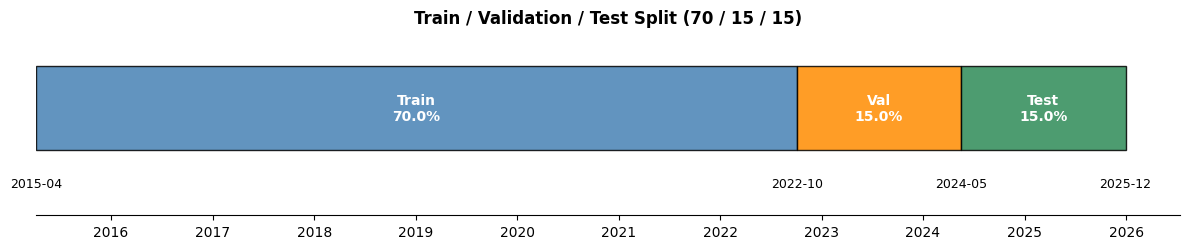

In [62]:
# Data split visualization (train / val / test timeline)
fig, ax = plt.subplots(figsize=(12, 2.6))

splits = [
    ("Train", train_idx[0], train_idx[-1], len(train_idx), "steelblue"),
    ("Val",   val_idx[0],   val_idx[-1],   len(val_idx),   "darkorange"),
    ("Test",  test_idx[0],  test_idx[-1],  len(test_idx),  "seagreen"),
]
total = sum(s[3] for s in splits)

for name, start, end, count, color in splits:
    pct   = count / total * 100
    left  = mdates.date2num(start)
    width = mdates.date2num(end) - left
    ax.barh(0, width, left=left, color=color, alpha=0.85, edgecolor="black", height=0.55)
    # Inside-bar label: name + % + day count
    ax.text(left + width / 2, 0, f"{name}\n{pct:.1f}%", ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    # Start date label below
    ax.text(left, -0.45, start.strftime("%Y-%m"), ha="center", va="top", fontsize=9)

# Final end-date label
ax.text(mdates.date2num(splits[-1][2]), -0.45, splits[-1][2].strftime("%Y-%m"), ha="center", va="top", fontsize=9)

ax.set_ylim(-0.7, 0.5)
ax.set_yticks([])
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Train / Validation / Test Split (70 / 15 / 15)", fontsize=12, fontweight="bold")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**MVO backtest**

Backtesting is the process of applying a trading strategy to historical data to evaluate its performance, profitability, and risk before risking real capital.

In [63]:
# MVO backtest (static weights applied to test period returns)
mvo_returns = test_r @ mvo_weights
mvo_cum     = (1 + mvo_returns).cumprod()

# Compute metrics
ann_return = mvo_returns.mean() * 252
ann_vol    = mvo_returns.std() * np.sqrt(252)
sharpe     = ann_return / ann_vol
cum_return = (mvo_cum.iloc[-1] - 1)
rolling_max = mvo_cum.cummax()
max_dd      = ((mvo_cum - rolling_max) / rolling_max).min()

# Build rows: (label, value)
rows = [
    ("Period",             f"{mvo_returns.index[0].date()} → {mvo_returns.index[-1].date()}"),
    ("Trading Days",       f"{len(mvo_returns)}"),
    ("Cumulative Return",  f"{cum_return * 100:>7.2f}%"),
    ("Annual Return",      f"{ann_return * 100:>7.2f}%"),
    ("Annual Volatility",  f"{ann_vol    * 100:>7.2f}%"),
    ("Sharpe Ratio",       f"{sharpe:>8.4f}"),
    ("Max Drawdown",       f"{max_dd     * 100:>7.2f}%"),
]

# Print Results
title = "Baseline MVO Model Performance"
label_w = max(len(r[0]) for r in rows)
value_w = max(len(r[1]) for r in rows)
total_w = label_w + value_w + 3

print(title)
print("=" * total_w)
for label, value in rows:
    print(f"{label:<{label_w}} : {value:>{value_w}}")
print("=" * total_w)

Baseline MVO Model Performance
Period            : 2024-05-17 → 2025-12-30
Trading Days      :                     406
Cumulative Return :                  31.86%
Annual Return     :                  17.72%
Annual Volatility :                  10.52%
Sharpe Ratio      :                  1.6842
Max Drawdown      :                  -9.17%


# **Dataset Preparation for ML**

**Normalize features**

In [64]:
# Normalize features (fit on train only, apply to all)
scaler   = StandardScaler()
feat_arr = features.copy()

# Training dataset transformation
feat_arr[feat_arr.index <  val_idx[0]] = scaler.fit_transform(feat_arr[feat_arr.index <  val_idx[0]])

# Validation and Testing dataset transformation
feat_arr[feat_arr.index >= val_idx[0]] = scaler.transform(feat_arr[feat_arr.index >= val_idx[0]])

print(f"Shape      : {feat_arr.shape}")
print(f"Train mean : {feat_arr[feat_arr.index < val_idx[0]].values.mean():.4f}")
print(f"Train std  : {feat_arr[feat_arr.index < val_idx[0]].values.std():.4f}")

Shape      : (2702, 110)
Train mean : 0.0000
Train std  : 1.0000


**Build Rolling Window Sequences and Target**

In [65]:
# Build rolling window sequences (X) and next-day return targets (y)
WINDOW = 21
arr = feat_arr.values

# Design X and y with sequential data
X = np.array([arr[i - WINDOW : i] for i in range(WINDOW, len(feat_arr))])
y = returns.loc[feat_arr.index].values[WINDOW:]
idx = feat_arr.index[WINDOW:]

# Split using pre-defined date boundaries from Block 6
train_m = idx < val_idx[0]
val_m = (idx >= val_idx[0]) & (idx < test_idx[0])
test_m = idx >= test_idx[0]

X_train, y_train = X[train_m], y[train_m]
X_val, y_val = X[val_m], y[val_m]
X_test, y_test = X[test_m], y[test_m]

# LSTM-specific feature columns: returns, lags, momentum only
lstm_cols  = [c for c in feat_arr.columns if any(x in c for x in ["_lag", "_mom"]) or c in returns.columns]
arr_lstm   = feat_arr[lstm_cols].values

X_lstm     = np.array([arr_lstm[i - WINDOW : i] for i in range(WINDOW, len(feat_arr))])
X_lstm_train = X_lstm[train_m]
X_lstm_val   = X_lstm[val_m]
X_lstm_test  = X_lstm[test_m]

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

X_train : (1870, 21, 110)  |  y_train : (1870, 10)
X_val   : (405, 21, 110)    |  y_val   : (405, 10)
X_test  : (406, 21, 110)   |  y_test  : (406, 10)


# **Custom Loss Function**

**Define portfolio loss function**

*   Sharpe Ratio = Return earned per unit of risk taken
*   Turnover = How much the portfolio weights change between periods




In [66]:
# Custom loss: negative Sharpe Ratio + turnover penalty
def portfolio_loss(weights, returns, prev_weights=None, lambda_turn=0.5, lambda_dd=0.5, eps=1e-8):
    # Daily portfolio returns
    port_returns = (weights * returns).sum(dim=1)

    # Annualized Sharpe Ratio (risk-free rate ≈ 0)
    sharpe = (port_returns.mean() * 252) / (port_returns.std() * np.sqrt(252) + eps)

    # Turnover penalty (L1 weight change vs previous period)
    if prev_weights is not None and prev_weights.shape[0] == weights.shape[0]:
        turnover = torch.abs(weights - prev_weights).sum(dim=1).mean()
    else:
        turnover = torch.tensor(0.0)

    # Drawdown penalty
    cum_returns = (1 + port_returns).cumprod(dim=0)
    rolling_max = cum_returns.cummax(dim=0)[0]
    drawdown = (cum_returns - rolling_max) / rolling_max
    dd_penalty = drawdown.min().abs()

    return -sharpe + lambda_turn * turnover + lambda_dd * dd_penalty

# **Machine Learning Models**

**Define Multilayer Perceptron (MLP) Model**

In [67]:
# MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_size, num_layers, n_assets, dropout=0.3):
        super().__init__()
        dims = [input_dim] + [hidden_size] * num_layers
        layers = []
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i+1]), nn.ReLU(), nn.Dropout(dropout)]
        layers.append(nn.Linear(dims[-1], n_assets))
        layers.append(nn.Softmax(dim=-1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

n_assets = len(returns.columns)
input_dim = X_train.shape[1] * X_train.shape[2]
mlp = MLP(input_dim=input_dim, hidden_size=64, num_layers=1, n_assets=n_assets)

print(mlp)
print(f"\nInput dim : {input_dim}  ({WINDOW} days × {X_train.shape[2]} features)")
print(f"Output dim  : {n_assets} assets")
print(f"Parameters  : {sum(p.numel() for p in mlp.parameters()):,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=2310, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=10, bias=True)
    (4): Softmax(dim=-1)
  )
)

Input dim : 2310  (21 days × 110 features)
Output dim  : 10 assets
Parameters  : 148,554


**Define Long Short-Term Memory (LSTM) Model**

In [68]:
# LSTM model
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_size, num_layers, n_assets, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_size, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.norm    = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden_size, hidden_size // 2)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(hidden_size // 2, n_assets)
        self.softmax = nn.Softmax(dim=-1)

        # Orthogonal init for recurrent weights
        for name, param in self.lstm.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        # normalize hidden state
        out = self.norm(h[-1])
        # dropout after norm
        out = self.dropout(out)
        # intermediate activation
        out = self.relu(self.fc1(out))
        return self.softmax(self.fc2(out))

n_assets  = len(returns.columns)
input_dim = X_lstm_train.shape[2]
lstm = LSTM(input_dim=input_dim, hidden_size=128, num_layers=2, n_assets=n_assets)

print(lstm)
print(f"\nInput dim   : {input_dim} features per timestep")
print(f"Sequence    : {WINDOW} days")
print(f"Output dim  : {n_assets} assets")
print(f"Parameters  : {sum(p.numel() for p in lstm.parameters()):,}")

LSTM(
  (lstm): LSTM(60, 128, num_layers=2, batch_first=True, dropout=0.3)
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
  (softmax): Softmax(dim=-1)
)

Input dim   : 60 features per timestep
Sequence    : 21 days
Output dim  : 10 assets
Parameters  : 238,538


**Training Loop**

In [69]:
# Training loop
def train_model(model, X_tr, y_tr, X_vl, y_vl, lr, epochs, batch_size=64, lambda_turn=0.5, lambda_dd=0.5, smooth_alpha=0.3, clip_grad=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_vl_t = torch.tensor(X_vl, dtype=torch.float32)
    y_vl_t = torch.tensor(y_vl, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=False, drop_last=True)

    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        prev_w = None
        for X_b, y_b in loader:
            w_raw = model(X_b)
            w = smooth_alpha * w_raw + (1 - smooth_alpha) * prev_w \
                         if prev_w is not None else w_raw
            loss = portfolio_loss(w, y_b, prev_w, lambda_turn, lambda_dd)
            optimizer.zero_grad()
            loss.backward()
            if clip_grad:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            prev_w = w_raw.detach()
        train_losses.append(epoch_loss / len(loader))

        model.eval()
        with torch.no_grad():
            w_val = model(X_vl_t)
            val_loss = portfolio_loss(w_val, y_vl_t, lambda_turn=lambda_turn, lambda_dd=lambda_dd).item()
        val_losses.append(val_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:>3} | Train Loss : {train_losses[-1]:.4f} | Val Loss : {val_loss:.4f}")

    return model, train_losses, val_losses, {"label"       : None,
                                             "best_val"    : min(val_losses),
                                             "final_train" : train_losses[-1],
                                             "final_val"   : val_losses[-1],
                                             "train_losses": train_losses,
                                             "val_losses"  : val_losses}

**Experiments Cases**

In [70]:
# MLP-focused experiments: higher capacity, stronger regularization
mlp_experiments = [
    {"label": "Baseline", "hidden_size": 64,  "num_layers": 1, "dropout": 0.2, "lr": 0.001,  "epochs": 100, "lambda_turn": 0.5, "lambda_dd": 0.5, "clip_grad": False},
    {"label": "Exp 1",    "hidden_size": 256, "num_layers": 2, "dropout": 0.5, "lr": 0.0003, "epochs": 150, "lambda_turn": 0.5, "lambda_dd": 0.5, "clip_grad": False},
    {"label": "Exp 2",    "hidden_size": 128, "num_layers": 2, "dropout": 0.3, "lr": 0.0003, "epochs": 150, "lambda_turn": 0.5, "lambda_dd": 0.5, "clip_grad": False},
    {"label": "Exp 3",    "hidden_size": 128, "num_layers": 2, "dropout": 0.3, "lr": 0.0003, "epochs": 150, "lambda_turn": 0.5, "lambda_dd": 0.5, "clip_grad": False},
    {"label": "Exp 4",    "hidden_size": 128, "num_layers": 2, "dropout": 0.4, "lr": 0.0003, "epochs": 200, "lambda_turn": 0.5, "lambda_dd": 0.5, "clip_grad": False},
]

# LSTM-focused experiments: lighter regularization, slower learning, more epochs
lstm_experiments = [
    {"label": "Baseline", "hidden_size": 64,  "num_layers": 1, "dropout": 0.0, "lr": 0.001,  "epochs": 100, "lambda_turn": 0.2, "lambda_dd": 0.2, "smooth_alpha": 0.0, "clip_grad": True},
    {"label": "Exp 1",    "hidden_size": 128, "num_layers": 2, "dropout": 0.2, "lr": 0.0005, "epochs": 150, "lambda_turn": 0.3, "lambda_dd": 0.3, "smooth_alpha": 0.0, "clip_grad": True},
    {"label": "Exp 2",    "hidden_size": 256, "num_layers": 2, "dropout": 0.2, "lr": 0.0003, "epochs": 200, "lambda_turn": 0.2, "lambda_dd": 0.5, "smooth_alpha": 0.0, "clip_grad": True},
    {"label": "Exp 3",    "hidden_size": 256, "num_layers": 2, "dropout": 0.2,  "lr": 0.0003, "epochs": 250, "lambda_turn": 0.3, "lambda_dd": 0.5, "smooth_alpha": 0.0, "clip_grad": True},
    {"label": "Exp 4",    "hidden_size": 256, "num_layers": 2, "dropout": 0.25, "lr": 0.0002, "epochs": 250, "lambda_turn": 0.3, "lambda_dd": 0.7, "smooth_alpha": 0.0, "clip_grad": True},
]

**Train MLP**

In [71]:
# Train MLP across experiments
input_dim = X_train.shape[1] * X_train.shape[2]
mlp_results = []

for exp in mlp_experiments:
    print(f"\n{exp['label']} | hidden_size={exp['hidden_size']} | num_layers={exp['num_layers']} | dropout={exp['dropout']} | lr={exp['lr']} | epochs={exp['epochs']}")
    print("-" * 80)

    model = MLP(input_dim=input_dim, hidden_size=exp["hidden_size"], num_layers=exp["num_layers"], n_assets=n_assets, dropout=exp["dropout"])

    model, train_losses, val_losses, result = train_model(
        model, X_train, y_train, X_val, y_val, lr=exp["lr"], epochs=exp["epochs"],
        lambda_turn=exp["lambda_turn"], lambda_dd=exp["lambda_dd"], clip_grad=exp.get("clip_grad", True))

    result["label"] = exp["label"]
    result["model"] = model
    mlp_results.append(result)

# Summary table
print("\nMLP Experiment Summary\n")
header = f"{'Label':<12} {'Best Val':>10} {'Final Train':>12} {'Final Val':>10}"
print(header)
print("-" * len(header))
for r in mlp_results:
    print(f"{r['label']:<12} {r['best_val']:>10.4f} {r['final_train']:>12.4f} {r['final_val']:>10.4f}")

# Best experiment
best_mlp = min(mlp_results, key=lambda r: r["best_val"])
print(f"\nBest MLP : {best_mlp['label']} | Best Val Loss : {best_mlp['best_val']:.4f}")


Baseline | hidden_size=64 | num_layers=1 | dropout=0.2 | lr=0.001 | epochs=100
--------------------------------------------------------------------------------
Epoch  10 | Train Loss : -3.8930 | Val Loss : -0.9892
Epoch  20 | Train Loss : -4.2897 | Val Loss : -0.9239
Epoch  30 | Train Loss : -4.8835 | Val Loss : -0.8617
Epoch  40 | Train Loss : -5.0697 | Val Loss : -0.9849
Epoch  50 | Train Loss : -5.2325 | Val Loss : -0.9021
Epoch  60 | Train Loss : -5.5876 | Val Loss : -1.1483
Epoch  70 | Train Loss : -5.5379 | Val Loss : -1.1325
Epoch  80 | Train Loss : -5.3770 | Val Loss : -1.2239
Epoch  90 | Train Loss : -5.2436 | Val Loss : -0.9684
Epoch 100 | Train Loss : -5.5737 | Val Loss : -0.5856

Exp 1 | hidden_size=256 | num_layers=2 | dropout=0.5 | lr=0.0003 | epochs=150
--------------------------------------------------------------------------------
Epoch  10 | Train Loss : -2.6241 | Val Loss : -0.9813
Epoch  20 | Train Loss : -3.9921 | Val Loss : -0.8734
Epoch  30 | Train Loss : -4.242

**Train LSTM**

In [73]:
# Train LSTM across experiments
input_dim = X_lstm_train.shape[2]
lstm_results = []

for exp in lstm_experiments:
    print(f"\n{exp['label']} | hidden_size={exp['hidden_size']} | num_layers={exp['num_layers']} | dropout={exp['dropout']} | lr={exp['lr']} | epochs={exp['epochs']}")
    print("-" * 80)

    model = LSTM(input_dim=input_dim, hidden_size=exp["hidden_size"], num_layers=exp["num_layers"], n_assets=n_assets, dropout=exp["dropout"])

    model, train_losses, val_losses, result = train_model(
        model, X_lstm_train, y_train, X_lstm_val, y_val,lr = exp["lr"], epochs=exp["epochs"],
        lambda_turn=exp["lambda_turn"], lambda_dd=exp["lambda_dd"],smooth_alpha=exp.get("smooth_alpha", 0.0), clip_grad=exp.get("clip_grad", True)
    )

    result["label"] = exp["label"]
    result["model"] = model
    lstm_results.append(result)

# Summary table
print("\nLSTM Experiment Summary\n")
header = f"{'Label':<12} {'Best Val':>10} {'Final Train':>12} {'Final Val':>10}"
print(header)
print("-" * len(header))
for r in lstm_results:
    print(f"{r['label']:<12} {r['best_val']:>10.4f} {r['final_train']:>12.4f} {r['final_val']:>10.4f}")

# Best experiment
best_lstm = min(lstm_results, key=lambda r: r["best_val"])
print(f"\nBest LSTM : {best_lstm['label']} | Best Val Loss : {best_lstm['best_val']:.4f}")


Baseline | hidden_size=64 | num_layers=1 | dropout=0.0 | lr=0.001 | epochs=100
--------------------------------------------------------------------------------
Epoch  10 | Train Loss : -1.6073 | Val Loss : -1.1991
Epoch  20 | Train Loss : -1.8957 | Val Loss : -1.1290
Epoch  30 | Train Loss : -2.0091 | Val Loss : -1.0489
Epoch  40 | Train Loss : -2.0387 | Val Loss : -0.9555
Epoch  50 | Train Loss : -2.0858 | Val Loss : -0.8957
Epoch  60 | Train Loss : -1.8151 | Val Loss : -0.8486
Epoch  70 | Train Loss : -1.9847 | Val Loss : -0.7811
Epoch  80 | Train Loss : -2.0828 | Val Loss : -0.7655
Epoch  90 | Train Loss : -2.1072 | Val Loss : -0.7864
Epoch 100 | Train Loss : -1.9803 | Val Loss : -0.8030

Exp 1 | hidden_size=128 | num_layers=2 | dropout=0.2 | lr=0.0005 | epochs=150
--------------------------------------------------------------------------------
Epoch  10 | Train Loss : -1.5003 | Val Loss : -0.9906
Epoch  20 | Train Loss : -1.8537 | Val Loss : -1.0537
Epoch  30 | Train Loss : -1.831

**Generate Weights**

In [85]:
# Generate portfolio weights on test set using best MLP and LSTM
X_test_t = torch.tensor(X_test, dtype=torch.float32)
X_lstm_test_t = torch.tensor(X_lstm_test, dtype=torch.float32)

# MLP weights
best_mlp["model"].eval()
with torch.no_grad():
    mlp_weights = best_mlp["model"](X_test_t).numpy()

# LSTM weights
best_lstm["model"].eval()
with torch.no_grad():
    lstm_weights = best_lstm["model"](X_lstm_test_t).numpy()

# Wrap in DataFrames with ticker columns and test dates
mlp_weights_df = pd.DataFrame(mlp_weights,  index=test_idx, columns=returns.columns)
lstm_weights_df = pd.DataFrame(lstm_weights, index=test_idx, columns=returns.columns)

print(f"MLP  weights shape : {mlp_weights_df.shape}")
print(f"LSTM weights shape : {lstm_weights_df.shape}")
print(f"\nMLP  mean weights :\n{mlp_weights_df.mean().round(4).to_string()}")
print(f"\nLSTM mean weights :\n{lstm_weights_df.mean().round(4).to_string()}")

MLP  weights shape : (406, 10)
LSTM weights shape : (406, 10)

MLP  mean weights :
Ticker
EEM    0.0000
EFA    0.0000
GLD    0.0766
IWM    0.0691
LQD    0.0000
QQQ    0.4189
SPY    0.0000
TLT    0.2197
VNQ    0.0000
XLE    0.2156

LSTM mean weights :
Ticker
EEM    0.0865
EFA    0.0204
GLD    0.2801
IWM    0.1694
LQD    0.1713
QQQ    0.0567
SPY    0.0105
TLT    0.0796
VNQ    0.0947
XLE    0.0307


**Backtest**

In [86]:
# Backtest function: apply portfolio weights to test period returns
def backtest(weights_df, returns):
    aligned_r = returns.loc[weights_df.index]
    port_r = (weights_df * aligned_r).sum(axis=1)
    cum_r = (1 + port_r).cumprod()
    ann_return = port_r.mean() * 252
    ann_vol = port_r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol
    rolling_max = cum_r.cummax()
    drawdown = (cum_r - rolling_max) / rolling_max
    max_dd = drawdown.min()

    return {"port_returns" : port_r,
            "cum_returns"  : cum_r,
            "ann_return"   : ann_return,
            "ann_vol"      : ann_vol,
            "sharpe"       : sharpe,
            "drawdown"     : drawdown,
            "max_dd"       : max_dd}

# Use mlp_weights_df and lstm_weights_df from "generate weights" block
mlp_bt = backtest(mlp_weights_df,  returns)
lstm_bt = backtest(lstm_weights_df, returns)

# Recompute MVO backtest through same function for fair comparison
mvo_weights_df_bt = pd.DataFrame(
    np.tile(mvo_weights.values, (len(mlp_weights_df), 1)),
    index=mlp_weights_df.index, columns=returns.columns
)
mvo_bt = backtest(mvo_weights_df_bt, returns)

print("Backtest Performance Summary\n")
header = f"{'Metric':<22} {'MVO':>10} {'MLP':>10} {'LSTM':>10}"
print(header)
print("-" * len(header))
print(f"{'Period':<28} {str(mlp_weights_df.index[0].date()):>10} → {str(mlp_weights_df.index[-1].date())}")
print(f"{'Cumulative Return':<22} {(mvo_bt['cum_returns'].iloc[-1]-1)*100:>9.2f}% {(mlp_bt['cum_returns'].iloc[-1]-1)*100:>9.2f}% {(lstm_bt['cum_returns'].iloc[-1]-1)*100:>9.2f}%")
print(f"{'Annual Return':<22} {mvo_bt['ann_return']*100:>9.2f}% {mlp_bt['ann_return']*100:>9.2f}% {lstm_bt['ann_return']*100:>9.2f}%")
print(f"{'Annual Volatility':<22} {mvo_bt['ann_vol']*100:>9.2f}% {mlp_bt['ann_vol']*100:>9.2f}% {lstm_bt['ann_vol']*100:>9.2f}%")
print(f"{'Sharpe Ratio':<22} {mvo_bt['sharpe']:>10.4f} {mlp_bt['sharpe']:>10.4f} {lstm_bt['sharpe']:>10.4f}")
print(f"{'Max Drawdown':<22} {mvo_bt['max_dd']*100:>9.2f}% {mlp_bt['max_dd']*100:>9.2f}% {lstm_bt['max_dd']*100:>9.2f}%")

Backtest Performance Summary

Metric                        MVO        MLP       LSTM
-------------------------------------------------------
Period                       2024-05-17 → 2025-12-30
Cumulative Return          31.86%     87.76%     44.18%
Annual Return              17.72%     40.99%     23.67%
Annual Volatility          10.52%     19.46%     13.79%
Sharpe Ratio               1.6842     2.1061     1.7167
Max Drawdown               -9.17%    -10.16%    -14.69%


In [87]:
# Comparison table: every experiment's Best Val Loss, Test Sharpe, Max Drawdown
def eval_on_test(model, X_test_tensor):
    model.eval()
    with torch.no_grad():
        w = model(X_test_tensor).numpy()
    w_df = pd.DataFrame(w, index=test_idx, columns=returns.columns)
    bt = backtest(w_df, returns)
    return bt["sharpe"], bt["max_dd"]

# Pre-build test tensors once
X_test_t_all = torch.tensor(X_test, dtype=torch.float32)
X_lstm_test_t_all = torch.tensor(X_lstm_test, dtype=torch.float32)

rows = []
for r in mlp_results:
    sharpe, mdd = eval_on_test(r["model"], X_test_t_all)
    rows.append({"Model": "MLP",  "Label": r["label"],
                 "Best Val Loss": r["best_val"],
                 "Test Sharpe":   sharpe,
                 "Max Drawdown":  mdd * 100})

for r in lstm_results:
    sharpe, mdd = eval_on_test(r["model"], X_lstm_test_t_all)
    rows.append({"Model": "LSTM", "Label": r["label"],
                 "Best Val Loss": r["best_val"],
                 "Test Sharpe":   sharpe,
                 "Max Drawdown":  mdd * 100})

comparison_df = pd.DataFrame(rows)

# Pretty print
print("Experiment Comparison Across All Configurations\n")
hdr = f"{'Model':<6} {'Label':<10} {'Best Val Loss':>15} {'Test Sharpe':>13} {'Max Drawdown':>15}"
print(hdr)
print("-" * len(hdr))
for _, row in comparison_df.iterrows():
    print(f"{row['Model']:<6} {row['Label']:<10} "
          f"{row['Best Val Loss']:>15.4f} "
          f"{row['Test Sharpe']:>13.4f} "
          f"{row['Max Drawdown']:>14.2f}%")

# Winners per metric
best_val_row = comparison_df.loc[comparison_df["Best Val Loss"].idxmin()]
best_sharpe_row = comparison_df.loc[comparison_df["Test Sharpe"].idxmax()]
best_dd_row = comparison_df.loc[comparison_df["Max Drawdown"].idxmax()]

print("\nBest per Metric:")
print(f"   Best Val Loss : {best_val_row['Model']} {best_val_row['Label']}  ({best_val_row['Best Val Loss']:.4f})")
print(f"   Best Sharpe   : {best_sharpe_row['Model']} {best_sharpe_row['Label']}  ({best_sharpe_row['Test Sharpe']:.4f})")
print(f"   Lowest |DD|   : {best_dd_row['Model']} {best_dd_row['Label']}  ({best_dd_row['Max Drawdown']:.2f}%)")

Experiment Comparison Across All Configurations

Model  Label        Best Val Loss   Test Sharpe    Max Drawdown
---------------------------------------------------------------
MLP    Baseline           -1.3535        1.5417         -22.82%
MLP    Exp 1              -1.7017        1.2898         -15.06%
MLP    Exp 2              -1.6853        1.4264         -17.29%
MLP    Exp 3              -1.3362        1.8059         -16.67%
MLP    Exp 4              -1.7935        2.1061         -10.16%
LSTM   Baseline           -1.3128        1.3781         -12.21%
LSTM   Exp 1              -1.2131        1.7845         -13.57%
LSTM   Exp 2              -1.2270        1.9631         -10.40%
LSTM   Exp 3              -1.3259        1.7167         -14.69%
LSTM   Exp 4              -1.1745        1.5778         -11.20%

Best per Metric:
   Best Val Loss : MLP Exp 4  (-1.7935)
   Best Sharpe   : MLP Exp 4  (2.1061)
   Lowest |DD|   : MLP Exp 4  (-10.16%)


# Overall Models Comparison

**Visualization**

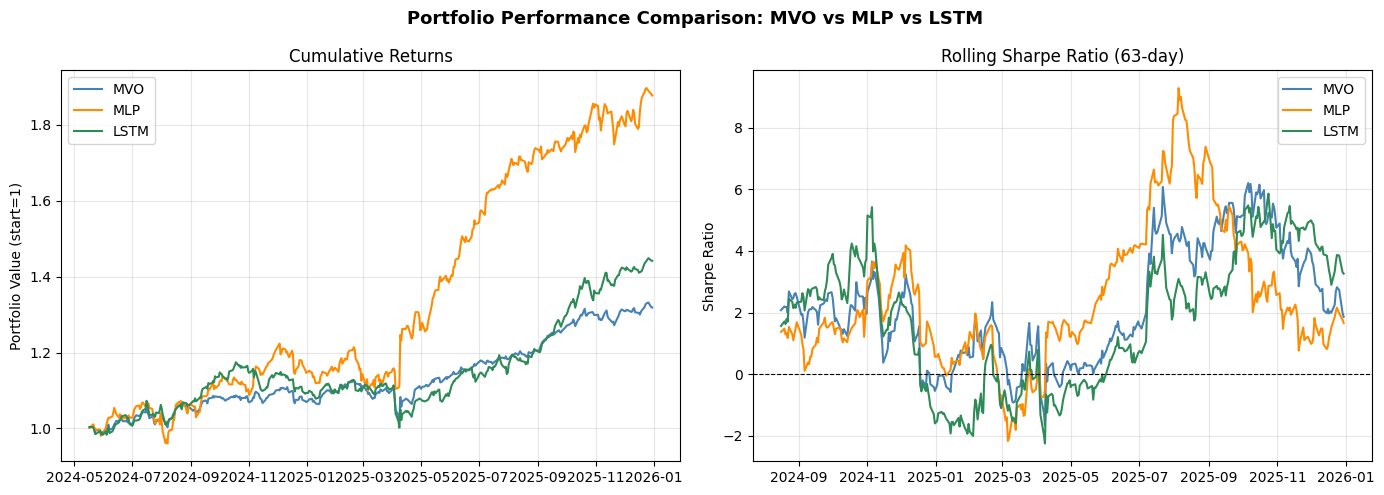

In [89]:
# Visualization: cumulative returns comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Portfolio Performance Comparison: MVO vs MLP vs LSTM", fontsize=13, fontweight="bold")

strategies = [("MVO", mvo_bt, "steelblue"), ("MLP", mlp_bt, "darkorange"), ("LSTM", lstm_bt, "seagreen")]

# Plot 1: Cumulative returns
ax = axes[0]
for label, bt, color in strategies:
    ax.plot(bt["cum_returns"], label=label, linewidth=1.5, color=color)
ax.set_title("Cumulative Returns")
ax.set_ylabel("Portfolio Value (start=1)")
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 2: Rolling Sharpe (63-day)
ax = axes[1]
for label, bt, color in strategies:
    r = bt["port_returns"]
    ax.plot((r.rolling(63).mean() * 252) / (r.rolling(63).std() * np.sqrt(252)),
            label=label, linewidth=1.5, color=color)
ax.set_title("Rolling Sharpe Ratio (63-day)")
ax.set_ylabel("Sharpe Ratio")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

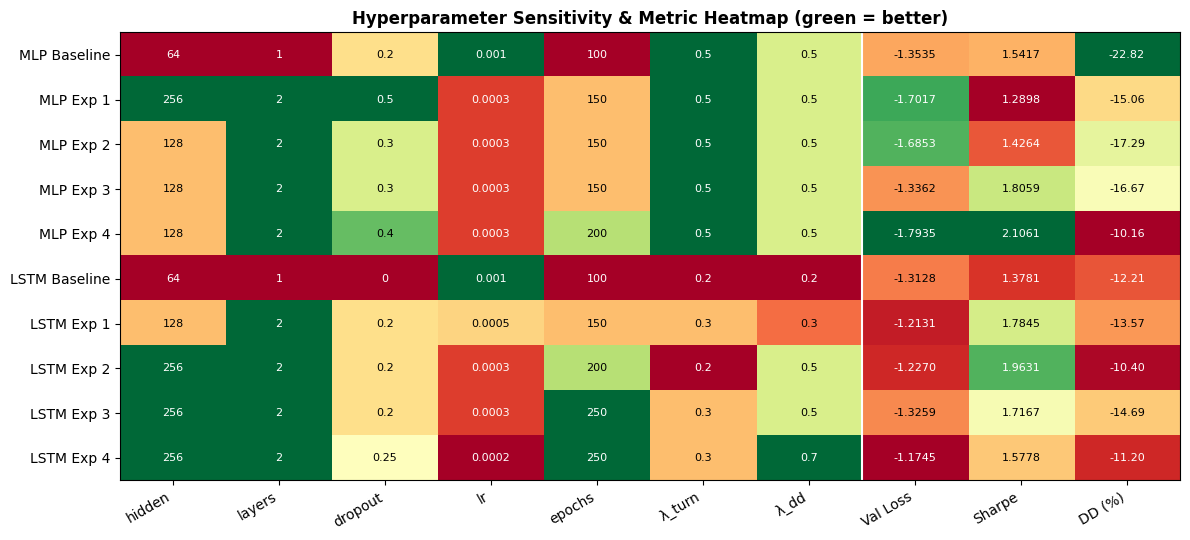

In [90]:
# Hyperparameter sensitivity heatmap across all experiments
def build_row(model_name, exp_cfg, result, X_test_tensor):
    sharpe, mdd = eval_on_test(result["model"], X_test_tensor)
    return {
        "Config": f"{model_name} {result['label']}",
        "hidden": exp_cfg["hidden_size"],
        "layers": exp_cfg["num_layers"],
        "dropout": exp_cfg["dropout"],
        "lr": exp_cfg["lr"],
        "epochs": exp_cfg["epochs"],
        "λ_turn": exp_cfg["lambda_turn"],
        "λ_dd": exp_cfg["lambda_dd"],
        "Val Loss": result["best_val"],
        "Sharpe": sharpe,
        "DD (%)": mdd * 100,
    }

# Build dataframe
rows = ([build_row("MLP", c, r, X_test_t_all) for c, r in zip(mlp_experiments, mlp_results)] +
    [build_row("LSTM", c, r, X_lstm_test_t_all) for c, r in zip(lstm_experiments, lstm_results)])
sens_df = pd.DataFrame(rows).set_index("Config")

# Normalize values for heatmap coloring
norm_df = sens_df.astype(float).apply(lambda x: 0.5 if x.max() == x.min() else (x - x.min()) / (x.max() - x.min()))

# For loss and drawdown, lower is better, so invert colors
norm_df[["Val Loss", "DD (%)"]] = 1 - norm_df[["Val Loss", "DD (%)"]]

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(norm_df.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

# Annotate cells with auto-adjusted font color
for i, row in enumerate(sens_df.index):
    for j, col in enumerate(sens_df.columns):
        v = sens_df.loc[row, col]
        txt = (
            f"{v:.4f}" if col in ["Val Loss", "Sharpe"] else
            f"{v:.2f}" if col == "DD (%)" else
            f"{v:g}")

        r, g, b, _ = im.cmap(im.norm(norm_df.loc[row, col]))
        brightness = 0.299 * r + 0.587 * g + 0.114 * b
        font_color = "black" if brightness > 0.55 else "white"

        ax.text(j, i, txt, ha="center", va="center", fontsize=8, color=font_color)

# Axis formatting
ax.set_xticks(range(len(sens_df.columns)))
ax.set_xticklabels(sens_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(sens_df.index)))
ax.set_yticklabels(sens_df.index)

ax.set_title(
    "Hyperparameter Sensitivity & Metric Heatmap (green = better)",
    fontsize=12,
    fontweight="bold"
)

# Divider between hyperparameters and metrics
ax.axvline(6.5, color="white", linewidth=1.5)
plt.tight_layout()
plt.show()

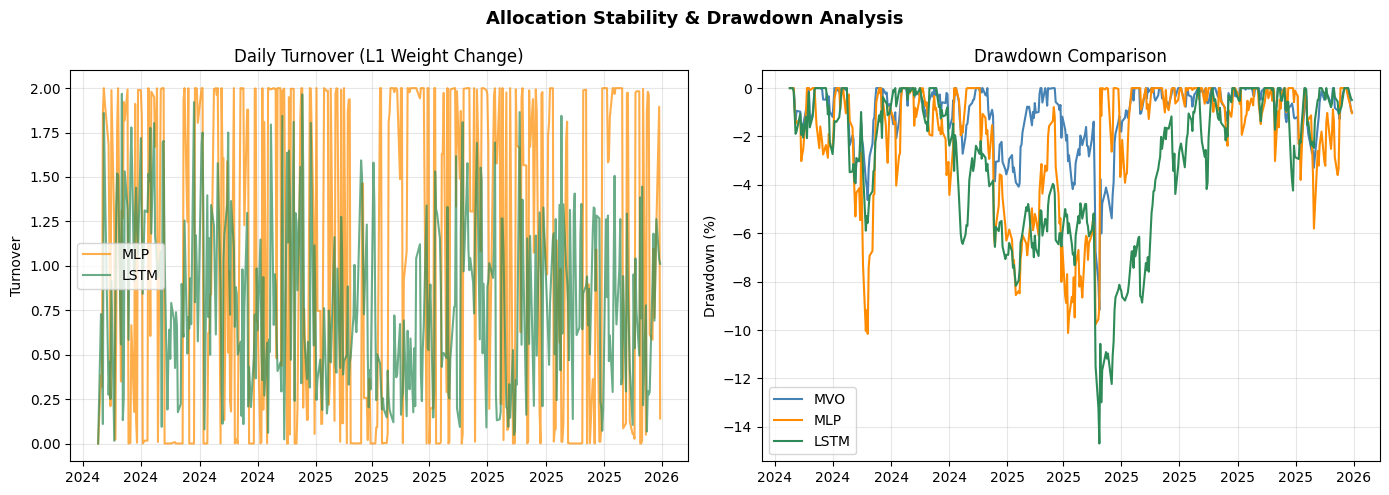

MLP  Mean Daily Turnover : 1.0710
LSTM Mean Daily Turnover : 0.7992

MVO  Max Drawdown : -9.17%
MLP  Max Drawdown : -10.16%
LSTM Max Drawdown : -14.69%


In [91]:
# Turnover | Drawdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Allocation Stability & Drawdown Analysis", fontsize=13, fontweight="bold")

# Daily turnover
mlp_turn  = mlp_weights_df.diff().abs().sum(axis=1)
lstm_turn = lstm_weights_df.diff().abs().sum(axis=1)
axes[0].plot(mlp_turn.index,  mlp_turn,  label="MLP",  color="darkorange", alpha=0.7)
axes[0].plot(lstm_turn.index, lstm_turn, label="LSTM", color="seagreen",   alpha=0.7)
axes[0].set_title("Daily Turnover (L1 Weight Change)")
axes[0].set_ylabel("Turnover")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown curves
axes[1].plot(mvo_bt["drawdown"].index,  mvo_bt["drawdown"]  * 100, label="MVO",  color="steelblue")
axes[1].plot(mlp_bt["drawdown"].index,  mlp_bt["drawdown"]  * 100, label="MLP",  color="darkorange")
axes[1].plot(lstm_bt["drawdown"].index, lstm_bt["drawdown"] * 100, label="LSTM", color="seagreen")
axes[1].set_title("Drawdown Comparison")
axes[1].set_ylabel("Drawdown (%)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MLP  Mean Daily Turnover : {mlp_turn.mean():.4f}")
print(f"LSTM Mean Daily Turnover : {lstm_turn.mean():.4f}")
print(f"\nMVO  Max Drawdown : {mvo_bt['max_dd']*100:.2f}%")
print(f"MLP  Max Drawdown : {mlp_bt['max_dd']*100:.2f}%")
print(f"LSTM Max Drawdown : {lstm_bt['max_dd']*100:.2f}%")

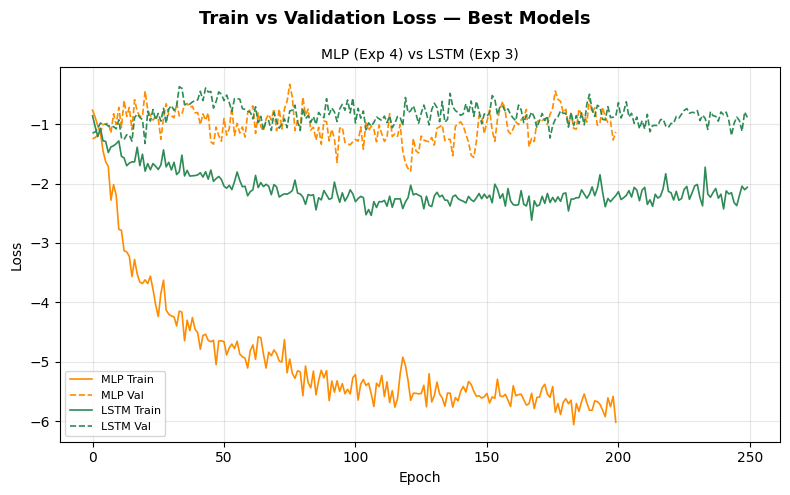

In [92]:
# Loss curves: best MLP and best LSTM only
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Train vs Validation Loss — Best Models", fontsize=13, fontweight="bold")

ax.plot(best_mlp["train_losses"],  label="MLP Train",  color="darkorange", linewidth=1.2)
ax.plot(best_mlp["val_losses"],    label="MLP Val",    color="darkorange", linewidth=1.2, linestyle="--")
ax.plot(best_lstm["train_losses"], label="LSTM Train", color="seagreen",   linewidth=1.2)
ax.plot(best_lstm["val_losses"],   label="LSTM Val",   color="seagreen",   linewidth=1.2, linestyle="--")
ax.set_title(f"MLP ({best_mlp['label']}) vs LSTM ({best_lstm['label']})", fontsize=10)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

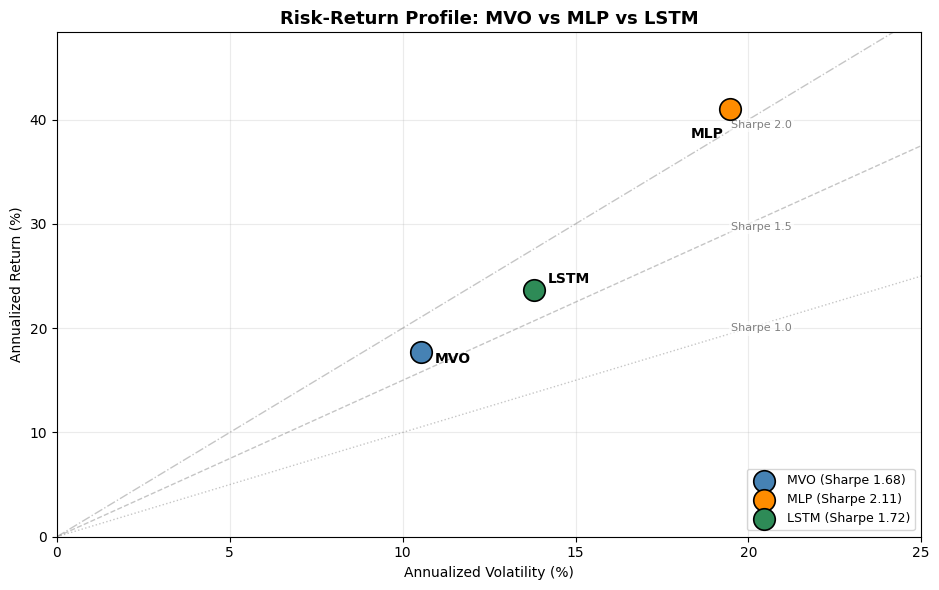

In [96]:
# Risk-return scatter: MVO vs MLP vs LSTM

fig, ax = plt.subplots(figsize=(9.5, 6))

strategies = [
    ("MVO", mvo_bt, "steelblue", (10, -5)),
    ("MLP", mlp_bt, "darkorange", (-28, -18)),
    ("LSTM", lstm_bt, "seagreen", (10, 8)),
]

x_vals = [bt["ann_vol"] * 100 for _, bt, _, _ in strategies]
y_vals = [bt["ann_return"] * 100 for _, bt, _, _ in strategies]
x_max, y_max = max(25, max(x_vals) * 1.2), max(40, max(y_vals) * 1.18)

ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)

vol_grid = np.linspace(0, x_max / 100, 200)

for s, ls in [(1.0, ":"), (1.5, "--"), (2.0, "-.")]:
    ax.plot(vol_grid * 100, s * vol_grid * 100, linestyle=ls, color="gray", alpha=0.45, linewidth=1)
    x_lab = min(x_max * 0.78, y_max * 0.90 / s)
    ax.text(x_lab, s * x_lab, f"Sharpe {s:.1f}", fontsize=8, color="gray", ha="left", va="bottom", bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.5))

for name, bt, color, offset in strategies:
    x, y = bt["ann_vol"] * 100, bt["ann_return"] * 100
    ax.scatter(x, y, s=240, color=color, edgecolor="black", linewidth=1.2, zorder=5, label=f"{name} (Sharpe {bt['sharpe']:.2f})")
    ax.annotate(name, xy=(x, y), xytext=offset, textcoords="offset points", fontsize=10, fontweight="bold", ha="left", va="center")

ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("Annualized Return (%)")
ax.set_title("Risk-Return Profile: MVO vs MLP vs LSTM", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.25)
ax.legend(loc="lower right", fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

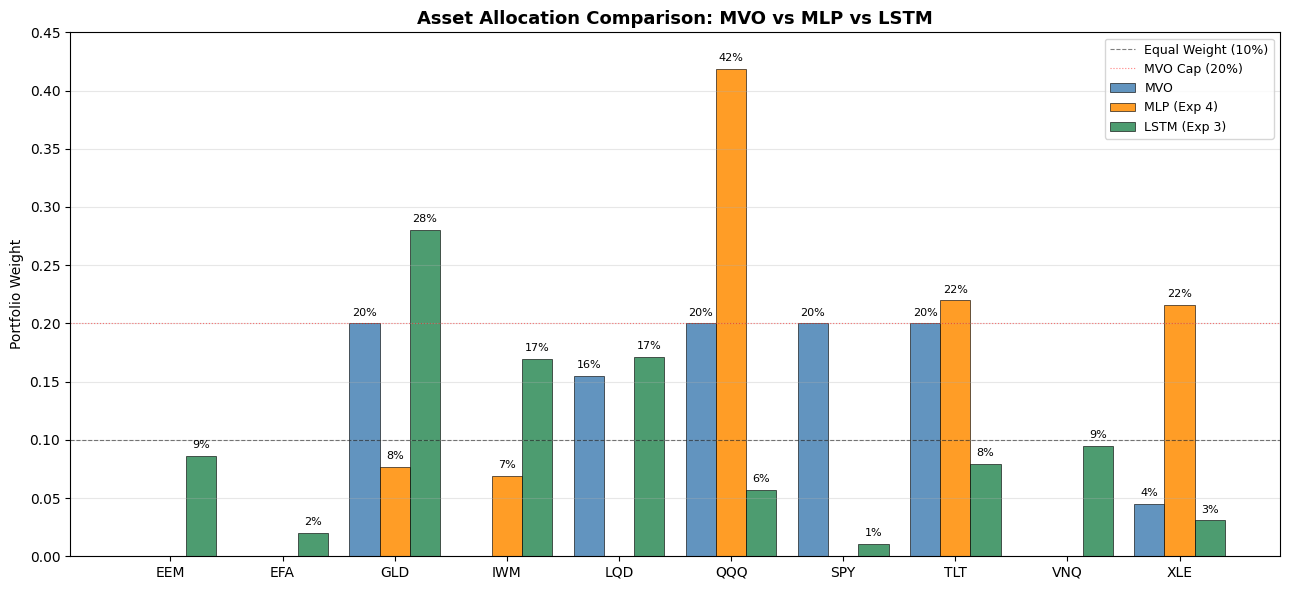

In [82]:
# Asset allocation comparison: MVO vs MLP vs LSTM
assets = returns.columns
x = np.arange(len(assets))
width = 0.27

weights = {
    "MVO": mvo_weights.values,
    f"MLP ({best_mlp['label']})": mlp_weights_df.mean().values,
    f"LSTM ({best_lstm['label']})": lstm_weights_df.mean().values,
}

colors = ["steelblue", "darkorange", "seagreen"]

fig, ax = plt.subplots(figsize=(13, 6))

for offset, (label, w), color in zip([-width, 0, width], weights.items(), colors):
    bars = ax.bar(x + offset, w, width, label=label, color=color, alpha=0.85, edgecolor="black", linewidth=0.5)

    for bar in bars:
        h = bar.get_height()
        if h > 0.005:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h * 100:.0f}%", ha="center", va="bottom", fontsize=8)

ax.axhline(0.10, color="black", linewidth=0.8, linestyle="--", alpha=0.5, label="Equal Weight (10%)")
ax.axhline(0.20, color="red", linewidth=0.8, linestyle=":", alpha=0.5, label="MVO Cap (20%)")

max_weight = max(np.max(w) for w in weights.values())

ax.set_xticks(x)
ax.set_xticklabels(assets)
ax.set_ylabel("Portfolio Weight")
ax.set_ylim(0, min(0.50, max_weight + 0.08))
ax.set_title("Asset Allocation Comparison: MVO vs MLP vs LSTM", fontsize=13, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

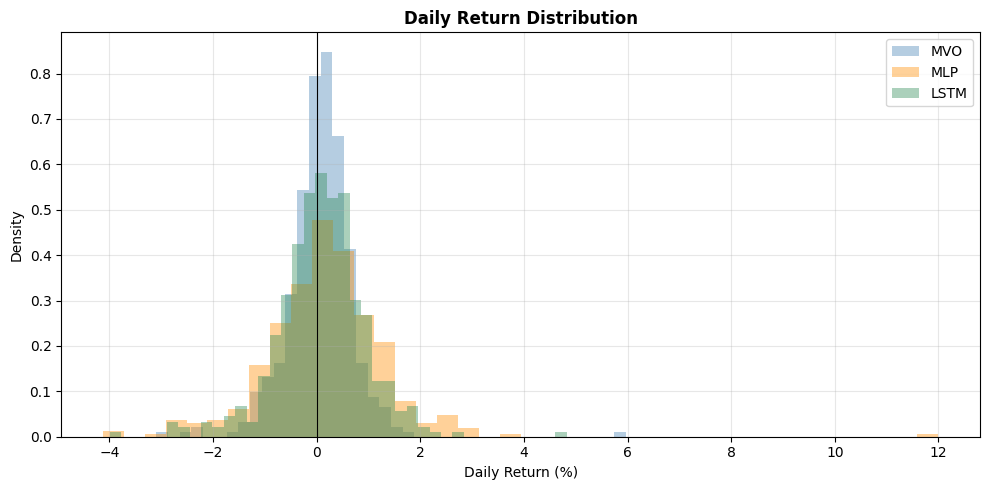

In [83]:
# Return distribution comparison (histogram + KDE)
fig, ax = plt.subplots(figsize=(10, 5))
for name, bt, color in [("MVO", mvo_bt, "steelblue"), ("MLP", mlp_bt, "darkorange"), ("LSTM", lstm_bt, "seagreen")]:
    ax.hist(bt["port_returns"] * 100, bins=40, alpha=0.4, color=color, label=name, density=True)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Density")
ax.set_title("Daily Return Distribution", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:
# Convert this Colab notebook with code + outputs to PDF

from google.colab import drive, files
import os

drive.mount("/content/drive")

notebook_path = "/content/drive/MyDrive/Colab Notebooks/CISC5800_MuhammadZaid_Maqsood.ipynb"
output_dir = "/content"

!apt-get update -qq
!apt-get install -y -qq texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
!jupyter nbconvert --to pdf "$notebook_path" --output-dir "$output_dir"

pdf_path = os.path.join(output_dir, "CISC5800_MuhammadZaid_Maqsood.pdf")
files.download(pdf_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/CISC5800_MuhammadZaid_Maqsood.ipynb to pdf
[NbConvertApp] Support files will be in CISC5800_MuhammadZaid_Maqsood_files/
[NbConvertApp] Making directory ./CISC5800_MuhammadZaid_Maqsood_files
[NbConvertApp] Writing 197975 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 801575 bytes to /content/CISC5800_MuhammadZaid

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>